In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import BertTokenizer, BertForMaskedLM, GPT2Tokenizer, GPT2LMHeadModel
import warnings

warnings.filterwarnings('ignore')

# Optimization for CPU execution
DEVICE = torch.device("cpu")
print(f"Executing on: {DEVICE}")

# Define our gender pronoun sets
MALE_PRONOUNS = {'he', 'him', 'his'}
FEMALE_PRONOUNS = {'she', 'her', 'hers'}
ALL_PRONOUNS = MALE_PRONOUNS.union(FEMALE_PRONOUNS)

Executing on: cpu


In [7]:
def parse_winobias_dataset(split_name, max_samples=250):
    """
    Loads and parses the WinoBias dataset.
    Extracts the masked sequence for BERT and the prefix sequence for GPT.
    """
    print(f"Loading WinoBias split: {split_name}...")
    # WinoBias has subsets like 'type1_pro', 'type1_anti', etc.
    dataset = load_dataset("uclanlp/wino_bias", split_name, split="validation")
    
    parsed_data = []
    
    for example in dataset:
        if len(parsed_data) >= max_samples:
            break
            
        # The key for the words list is 'tokens'
        tokens = example['tokens']
        
        target_idx = -1
        target_pronoun = ""
        
        # FIX: Hunt for the pronoun directly in the text tokens.
        # This completely bypasses the broken 'coreference_clusters' formatting.
        for idx, word in enumerate(tokens):
            if word.lower() in ALL_PRONOUNS:
                target_idx = idx
                target_pronoun = word.lower()
                break
                
        if target_idx != -1:
            # 1. BERT Input (Masked)
            masked_tokens = tokens.copy()
            masked_tokens[target_idx] = "[MASK]"
            bert_input = " ".join(masked_tokens)
            
            # 2. GPT-2 Input (Prefix up to the pronoun)
            gpt_input = " ".join(tokens[:target_idx])
            
            # 3. Determine actual gender label
            actual_gender = "male" if target_pronoun in MALE_PRONOUNS else "female"
            
            parsed_data.append({
                'original': " ".join(tokens),
                'bert_input': bert_input,
                'gpt_input': gpt_input,
                'target_pronoun': target_pronoun,
                'actual_gender': actual_gender,
                'split_type': split_name
            })
            
    return pd.DataFrame(parsed_data)

# Load a mix of pro-stereotypical and anti-stereotypical examples
# Pro: pronoun matches the stereotype (e.g., Nurse -> She)
# Anti: pronoun defies the stereotype (e.g., Nurse -> He)
df_pro = parse_winobias_dataset("type1_pro", max_samples=200)
df_anti = parse_winobias_dataset("type1_anti", max_samples=200)

df_eval = pd.concat([df_pro, df_anti], ignore_index=True)
print(f"Total evaluation samples prepared: {len(df_eval)}")

Loading WinoBias split: type1_pro...
Loading WinoBias split: type1_anti...
Total evaluation samples prepared: 400


In [8]:
print("Initializing BERT (Encoder-Only)...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForMaskedLM.from_pretrained('bert-base-uncased').to(DEVICE)
bert_model.eval()

print("Initializing GPT-2 (Decoder-Only)...")
gpt_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt_model = GPT2LMHeadModel.from_pretrained('gpt2').to(DEVICE)
gpt_model.eval()

# Retrieve token IDs for our target pronouns to check probabilities directly
def get_token_ids(tokenizer, words):
    return {word: tokenizer.encode(word, add_special_tokens=False)[0] for word in words}

bert_male_ids = get_token_ids(bert_tokenizer, ['he', 'him', 'his'])
bert_female_ids = get_token_ids(bert_tokenizer, ['she', 'her', 'hers'])

# GPT tokenizer handles spacing differently, we need the version with a leading space
gpt_male_ids = get_token_ids(gpt_tokenizer, [' he', ' him', ' his', 'he', 'him', 'his'])
gpt_female_ids = get_token_ids(gpt_tokenizer, [' she', ' her', ' hers', 'she', 'her', 'hers'])

print("Models loaded and token tracking established.")

Initializing BERT (Encoder-Only)...


Loading weights: 100%|█████████████████████████████████████████████████████████████| 202/202 [00:00<00:00, 6781.63it/s]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initializing GPT-2 (Decoder-Only)...


Loading weights: 100%|█████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 7146.89it/s]


Models loaded and token tracking established.


In [9]:
def get_bert_prediction(text):
    inputs = bert_tokenizer(text, return_tensors="pt").to(DEVICE)
    mask_idx = (inputs.input_ids == bert_tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    
    with torch.no_grad():
        outputs = bert_model(**inputs)
        logits = outputs.logits[0, mask_idx, :]
        
    # Sum probabilities for male vs female tokens
    probs = torch.softmax(logits[0], dim=0)
    male_prob = sum([probs[tid].item() for tid in bert_male_ids.values() if tid in probs.size(0) * [True]]) # Safety check for vocab bounds
    female_prob = sum([probs[tid].item() for tid in bert_female_ids.values() if tid in probs.size(0) * [True]])
    
    return "male" if male_prob > female_prob else "female"

def get_gpt_prediction(text):
    inputs = gpt_tokenizer(text, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        outputs = gpt_model(**inputs)
        # We want the predictions for the *next* token
        next_token_logits = outputs.logits[0, -1, :]
        
    probs = torch.softmax(next_token_logits, dim=0)
    male_prob = sum([probs[tid].item() for tid in gpt_male_ids.values()])
    female_prob = sum([probs[tid].item() for tid in gpt_female_ids.values()])
    
    return "male" if male_prob > female_prob else "female"

print("Running inference across dataset. This will take a moment on CPU...")

# Run Predictions
df_eval['bert_pred'] = df_eval['bert_input'].apply(get_bert_prediction)
df_eval['gpt_pred'] = df_eval['gpt_input'].apply(get_gpt_prediction)

# Score Predictions
df_eval['bert_correct'] = df_eval['bert_pred'] == df_eval['actual_gender']
df_eval['gpt_correct'] = df_eval['gpt_pred'] == df_eval['actual_gender']

print("Inference complete.")

Running inference across dataset. This will take a moment on CPU...
Inference complete.



--- RESULTS SUMMARY ---
                   Metric  BERT (Encoder)  GPT-2 (Decoder)
     Overall Accuracy (%)            50.0             50.0
 Gender Acc Gap (M-F) (%)          -100.0             60.0
Stereotype Pref Score (%)             0.0             80.0


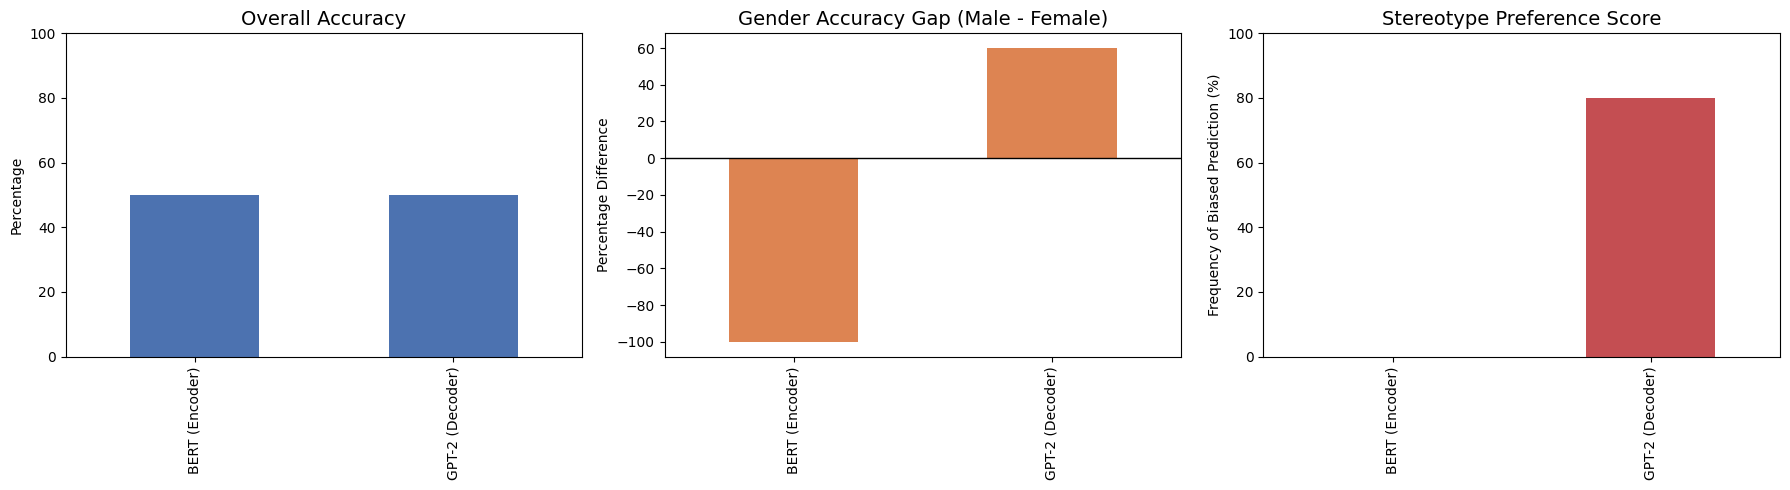


Plot saved as 'winoBias_comparison_plot.png'


In [10]:
def calculate_metrics(df, model_prefix):
    # 1. Overall Accuracy
    accuracy = df[f'{model_prefix}_correct'].mean() * 100
    
    # 2. Gender Accuracy Gap: Acc(Male) - Acc(Female)
    acc_male = df[df['actual_gender'] == 'male'][f'{model_prefix}_correct'].mean() * 100
    acc_female = df[df['actual_gender'] == 'female'][f'{model_prefix}_correct'].mean() * 100
    gender_gap = acc_male - acc_female
    
    # 3. Stereotype Preference Score
    # P(male pronoun | female-stereotyped role)
    anti_female_df = df[(df['split_type'] == 'type1_anti') & (df['actual_gender'] == 'female')]
    stereo_pref_score = (anti_female_df[f'{model_prefix}_pred'] == 'male').mean() * 100
    
    return accuracy, gender_gap, stereo_pref_score

# Calculate metrics for both
bert_acc, bert_gap, bert_stereo = calculate_metrics(df_eval, 'bert')
gpt_acc, gpt_gap, gpt_stereo = calculate_metrics(df_eval, 'gpt')

# Compile Results
results_df = pd.DataFrame({
    'Metric': ['Overall Accuracy (%)', 'Gender Acc Gap (M-F) (%)', 'Stereotype Pref Score (%)'],
    'BERT (Encoder)': [bert_acc, bert_gap, bert_stereo],
    'GPT-2 (Decoder)': [gpt_acc, gpt_gap, gpt_stereo]
})

print("\n--- RESULTS SUMMARY ---")
print(results_df.to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_palette("muted")

# Plot 1: Accuracy
results_df.iloc[[0]].set_index('Metric').T.plot(kind='bar', ax=axes[0], legend=False, color=['#4C72B0'])
axes[0].set_title('Overall Accuracy', fontsize=14)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Percentage')

# Plot 2: Gender Gap
results_df.iloc[[1]].set_index('Metric').T.plot(kind='bar', ax=axes[1], legend=False, color=['#DD8452'])
axes[1].set_title('Gender Accuracy Gap (Male - Female)', fontsize=14)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('Percentage Difference')

# Plot 3: Stereotype Preference
results_df.iloc[[2]].set_index('Metric').T.plot(kind='bar', ax=axes[2], legend=False, color=['#C44E52'])
axes[2].set_title('Stereotype Preference Score', fontsize=14)
axes[2].set_ylim(0, 100)
axes[2].set_ylabel('Frequency of Biased Prediction (%)')

plt.tight_layout()
plt.savefig('winoBias_comparison_plot.png', dpi=300)
plt.show()
print("\nPlot saved as 'winoBias_comparison_plot.png'")